In [1]:
import sys
from pyprojroot import here
sys.path.append(str(here()))

In [2]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import os


Manual Mode --> 7, Acc Threshold .5
So if you tell it "Hey we expect X jumps it works good", but its automatic (what we want) needs re-adjustment

Best with automatic so far (small sample)

keep time resolution at 0.000001

iteration range --> 10
acc threshold   --> 0.05

iteration range --> 36
acc threshold   --> 0.15

iteration range --> 50
acc threshold   --> 0.15


In [3]:


pio.renderers.default = "notebook_connected+png"

root = "../../../"
output_dir = "trajectories"

os.makedirs(output_dir, exist_ok=True)

def plot_predictions(trajectory_length, iteration):
    true_df = pd.read_csv(
        root
        + f"db/trajectories/trajectories/trajectory_{trajectory_length}k_{iteration}.csv"
    )
    pred_df = pd.read_csv(
        root
        + f"db/trajectories/bead_positions/StepFit_Result/bead_position_{trajectory_length}k_{iteration}_fits.txt"
    )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            y=true_df["bead_positions"],
            mode="lines",
            name="Bead Positions",
            line=dict(color="grey"),
            opacity=0.4,
        )
    )

    fig.add_trace(
        go.Scatter(
            y=true_df["target_theta"],
            mode="lines",
            name="True State",
            line=dict(color="blue"),
        )
    )

    fig.add_trace(
        go.Scatter(
            y=pred_df["FinalFit"],
            mode="lines",
            name="Predicted (ASF)",
            line=dict(color="orange", width=2),
        )
    )

    fig.update_layout(
        title=f"Predictions vs True States (Trajectory Length: {trajectory_length}k)",
        xaxis_title="Index",
        yaxis_title="Values",
        xaxis=dict(rangeslider=dict(visible=True)),
        template="plotly_white",
        hovermode="x unified",
    )

    fig.show()

    filename = f"trajectory_{trajectory_length}k_{iteration}_plot.png"
    filepath = os.path.join(output_dir, filename)
    fig.write_image(filepath)
    print(f"Saved plot to: {filepath}")

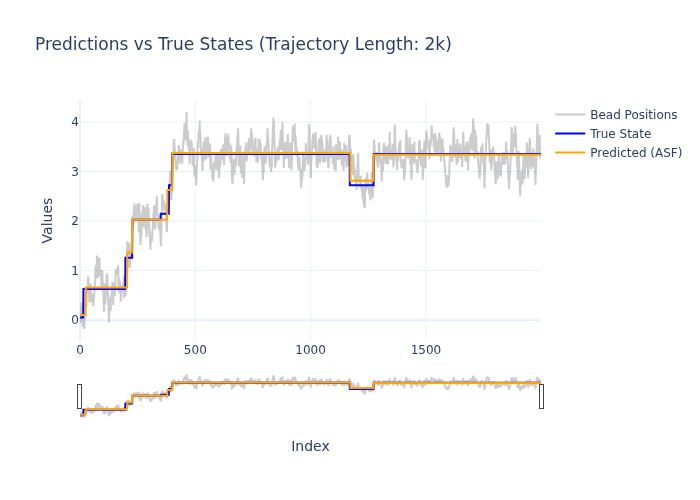

Saved plot to: trajectories/trajectory_2k_1_plot.png


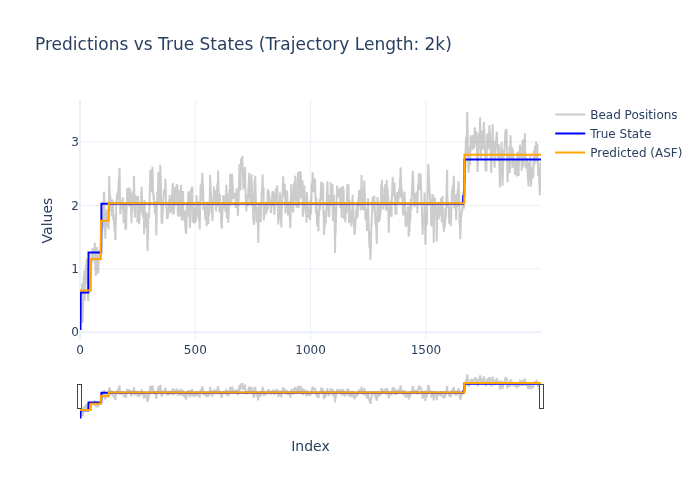

Saved plot to: trajectories/trajectory_2k_2_plot.png


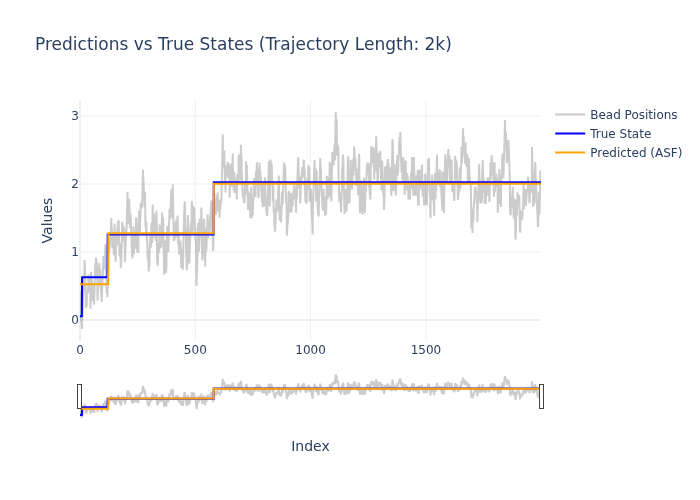

Saved plot to: trajectories/trajectory_2k_3_plot.png


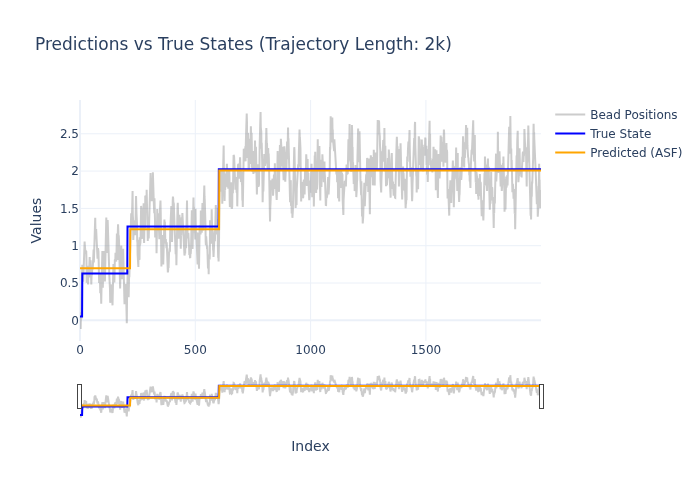

Saved plot to: trajectories/trajectory_2k_4_plot.png


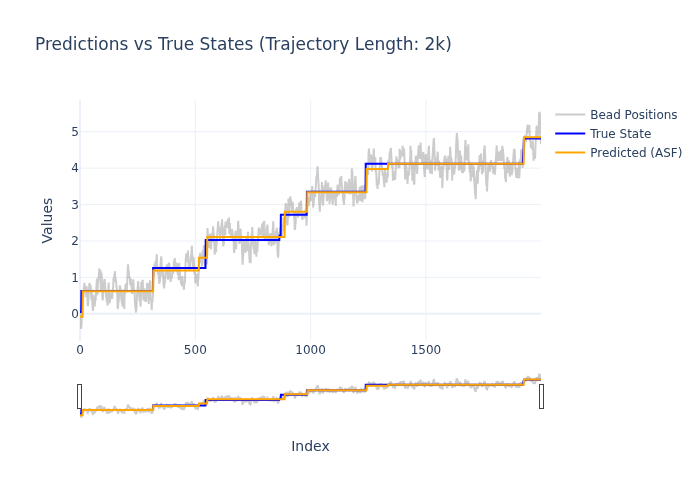

Saved plot to: trajectories/trajectory_2k_5_plot.png


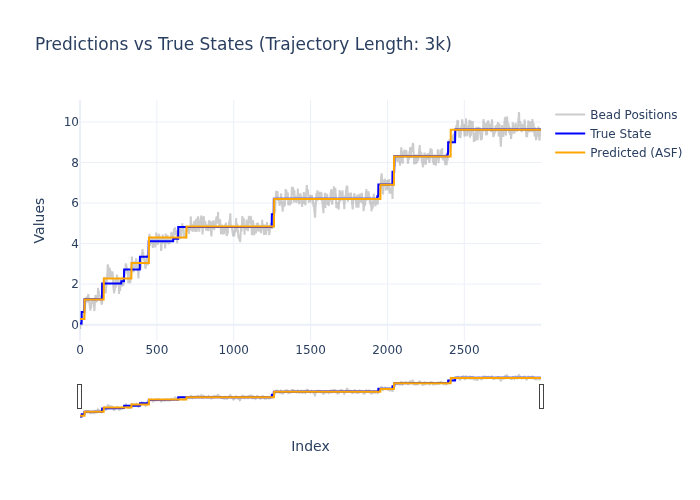

Saved plot to: trajectories/trajectory_3k_1_plot.png


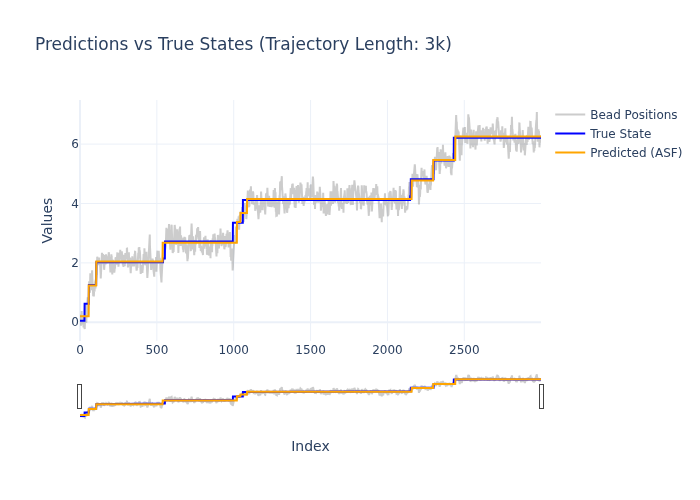

Saved plot to: trajectories/trajectory_3k_2_plot.png


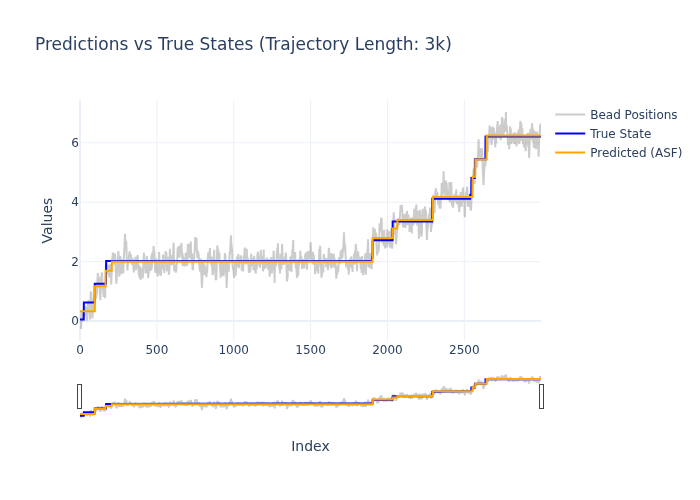

Saved plot to: trajectories/trajectory_3k_3_plot.png


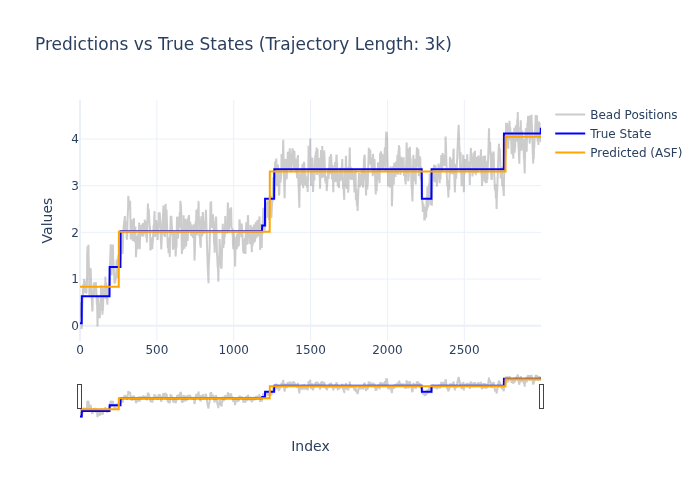

Saved plot to: trajectories/trajectory_3k_4_plot.png


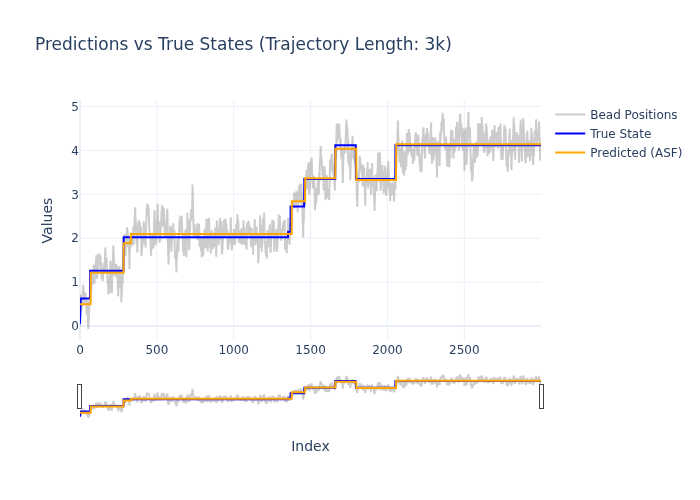

Saved plot to: trajectories/trajectory_3k_5_plot.png


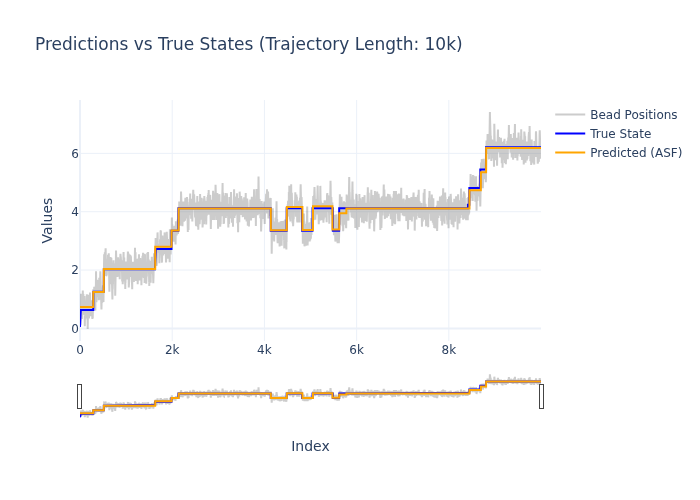

Saved plot to: trajectories/trajectory_10k_1_plot.png


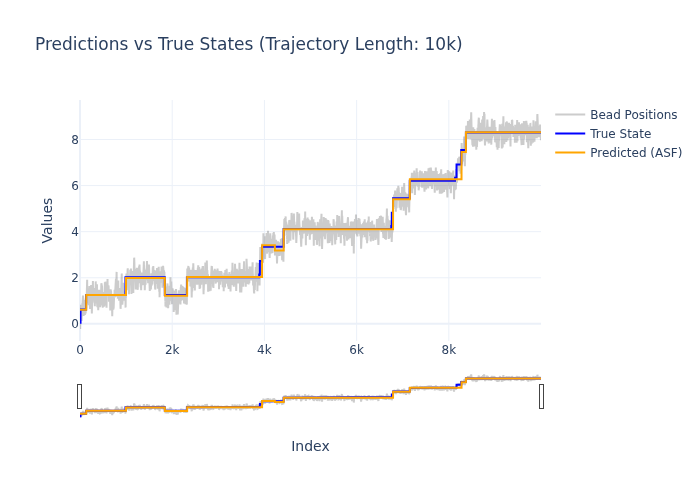

Saved plot to: trajectories/trajectory_10k_2_plot.png


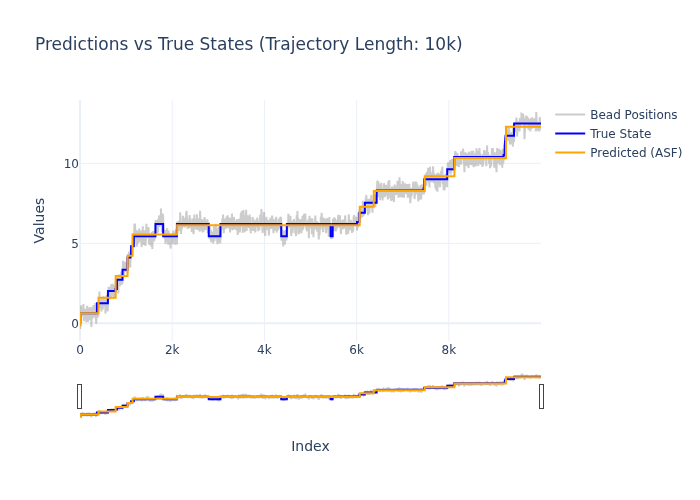

Saved plot to: trajectories/trajectory_10k_3_plot.png


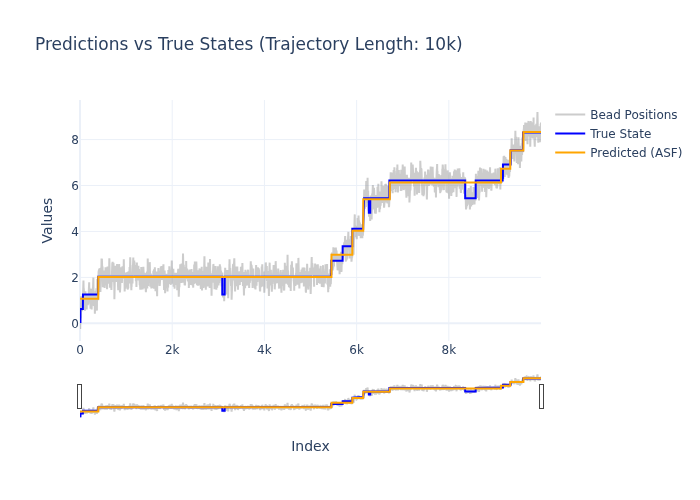

Saved plot to: trajectories/trajectory_10k_4_plot.png


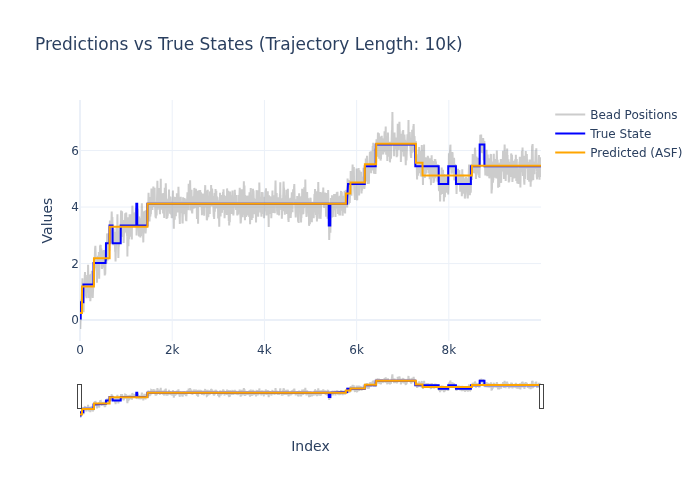

Saved plot to: trajectories/trajectory_10k_5_plot.png


In [4]:
traj_lengths = ["2", "3", "10"]
for tl in traj_lengths:
    for i in range(1, 6):
        plot_predictions(tl, i)